# Wavelet Source Detection for 3-D Spectral Cubes

Per-slice starlet (à trous IUWT) detection above diffuse emission — applied to synthetic toy cubes.

**Strategy:**  
The starlet transform decomposes each spectral slice into fine detail bands (compact sources) and a coarse residual (diffuse emission). By thresholding only the fine scales we detect compact sources *above* the diffuse halo. Sources are found globally on the max-projected significance map, then measured per channel within Voronoi territories.

**Pipeline:**  
1. Per-channel significance maps (fine starlet scales, MAD noise, optional diffuse subtraction)  
2. Max-project → global significance  
3. `peak_local_max` → N source peaks  
4. Voronoi assignment → N territories  
5. Per-channel footprint = connected component at peak pixel within territory
6. **Ground-truth comparison:** detected footprints & bboxes vs. clean individual galaxy cubes stored in the HDF5 file

## Imports

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path
from typing import NamedTuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib
from scipy.ndimage import center_of_mass, label as nd_label
from skimage.measure import regionprops

import sys as _sys
from pathlib import Path as _Path
_scripts_wavelet = _Path('../scripts')
if str(_scripts_wavelet) not in _sys.path:
    _sys.path.insert(0, str(_scripts_wavelet))

from utils import add_beam

## Toy Cube Loader

Loads a synthetic toy cube from an HDF5 file.  All metadata (beam, velocities, pixel scale, galaxy positions) are read directly from the file.

| variable | source |
|---|---|
| `cube` | `h5['cube']`, shape (n_ch, H, W), float32 |
| `vel_array` | `h5['channel_velocities_km_s']`, shape (n_ch,) |
| `pixscale_kpc` | `h5.attrs['spatial_resolution_kpc_per_px']` |
| `BMAJ_PIX` / `BMIN_PIX` / `BPA_DEG` | `h5['beam'].attrs` |
| `n_gals` / galaxy positions | `h5.attrs['n_gals']`, `h5['galaxies/positions_xyz_px']` |

`active_channels` with `threshold_frac=0.16` selects emission-bright channels.

In [2]:
import h5py

_CUBE_PATH = Path('../../../data/all_cubes/cube_3.h5')

def active_channels(cube: np.ndarray, threshold_frac: float = 0.05) -> list[int]:
    flux = np.nansum(np.clip(cube, 0.0, None), axis=(1, 2))
    thresh = threshold_frac * float(flux.max())
    return [int(i) for i in np.where(flux >= thresh)[0]]

with h5py.File(_CUBE_PATH, 'r') as _f:
    cube      = _f['cube'][:].astype(np.float32)
    vel_array = _f['channel_velocities_km_s'][:].astype(np.float64)

    BMAJ_PIX  = float(_f['beam'].attrs['bmaj_px'])
    BMIN_PIX  = float(_f['beam'].attrs['bmin_px'])
    BPA_DEG   = float(_f['beam'].attrs['bpa_deg'])

    pixscale_kpc = float(_f.attrs['spatial_resolution_kpc_per_px'])
    n_gals       = int(_f.attrs['n_gals'])
    n_satellites = int(_f.attrs.get('n_satellites', 0))
    diffuse      = bool(_f.attrs.get('diffuse_emission', False))

    # ground-truth data (used in comparison cell at the end)
    _gal_cubes     = _f['galaxies/cubes'][:].astype(np.float32)   # (n_gals, n_ch, H, W)
    _gal_pos_xyz   = _f['galaxies/positions_xyz_px'][:]            # (n_gals, 3): x,y,z pixel
    _gal_types_raw = _f['galaxies/types'][:]                       # (n_gals,) bytes
    _gal_types     = [t.decode() if isinstance(t, bytes) else str(t) for t in _gal_types_raw]

np.nan_to_num(cube, copy=False, nan=0.0)
np.clip(cube, 0.0, None, out=cube)

n_ch, H, W = cube.shape
_RESULTS_DIR = f'../results/toy_cube_{_CUBE_PATH.stem}'

print(f'Toy cube ({_CUBE_PATH.name}) : {cube.shape}')
print(f'Flux range                   : [{cube.min():.3e}, {cube.max():.3e}]')
print(f'Noise std (global)           : {cube.std():.3e}')
print(f'Pixel scale                  : {pixscale_kpc:.4f} kpc/px')
print(f'Beam                         : {BMAJ_PIX:.1f} x {BMIN_PIX:.1f} px, PA={BPA_DEG:.1f} deg')
print(f'Velocity range               : [{vel_array.min():.1f}, {vel_array.max():.1f}] km/s')
print(f'Galaxies                     : {n_gals} total ({n_satellites} satellite(s))')
print(f'Diffuse emission             : {diffuse}')
print(f'Galaxy types                 : {_gal_types}')

channel_list = active_channels(cube, threshold_frac=0.16)
channel_list = list(range(max(0, channel_list[0] - 5),
                          min(n_ch, channel_list[-1] + 5)))
print(f'Active channels              : {len(channel_list)}')
print(f'  ch {channel_list[0]}–{channel_list[-1]}')

thresh_frac = 0.015
TOY_THRESH  = thresh_frac * float(cube.max())
print(f'Detection floor              : {TOY_THRESH:.3e}  ({thresh_frac} × cube.max())')

Toy cube (cube_3.h5) : (64, 96, 96)
Flux range                   : [0.000e+00, 7.174e-02]
Noise std (global)           : 1.297e-03
Pixel scale                  : 1.2695 kpc/px
Beam                         : 4.0 x 4.0 px, PA=0.0 deg
Velocity range               : [-590.6, 590.6] km/s
Galaxies                     : 3 total (2 satellite(s))
Diffuse emission             : True
Galaxy types                 : ['central', 'satellite', 'satellite']
Active channels              : 31
  ch 16–46
Detection floor              : 1.076e-03  (0.015 × cube.max())


## Run Wavelet + Optical Flow Tracker

[run_flow_tracker]  cube=(64, 96, 96)  channels=31  (ch 16–46)
  wavelet: scales=5  k_sigma=5.0  use_scale=2  min_area=5  thresh=0.001076049730181694  mean_map_sigma=True
  tracker: min_match_overlap=5  min_split_overlap=3  max_gap_dist=15.0  max_gap_channels=5  min_displacement=3.0

[Stage 0] Per-channel wavelet detection...
  → 31 channels processed  |  24 with detections  |  56 total blobs

[Stage 1] Computing masked TV-L1 optical flow for 30 channel pairs...
  → 30 flow pairs computed.

[Stage 2] Linking tracks across 31 channels (30 transitions)...
  Seeded 0 track(s) from channel 16 (0 blob(s))
  → 5 total tracks created.

[Stage 3] Kinematic classification  (min_displacement=3.0 px)
  track  0  kinematic  ch 20–46  disp=52.9 px
  track  1  kinematic  ch 22–39  disp=42.2 px
  track  2  kinematic  ch 27–40  disp=41.8 px
  track  3  kinematic  ch 30–46  disp=3.6 px
  track  4  kinematic  ch 30–45  disp=5.2 px
  → 5 kinematic  |  0 static

[Stage 5] Grouping into sources and removin

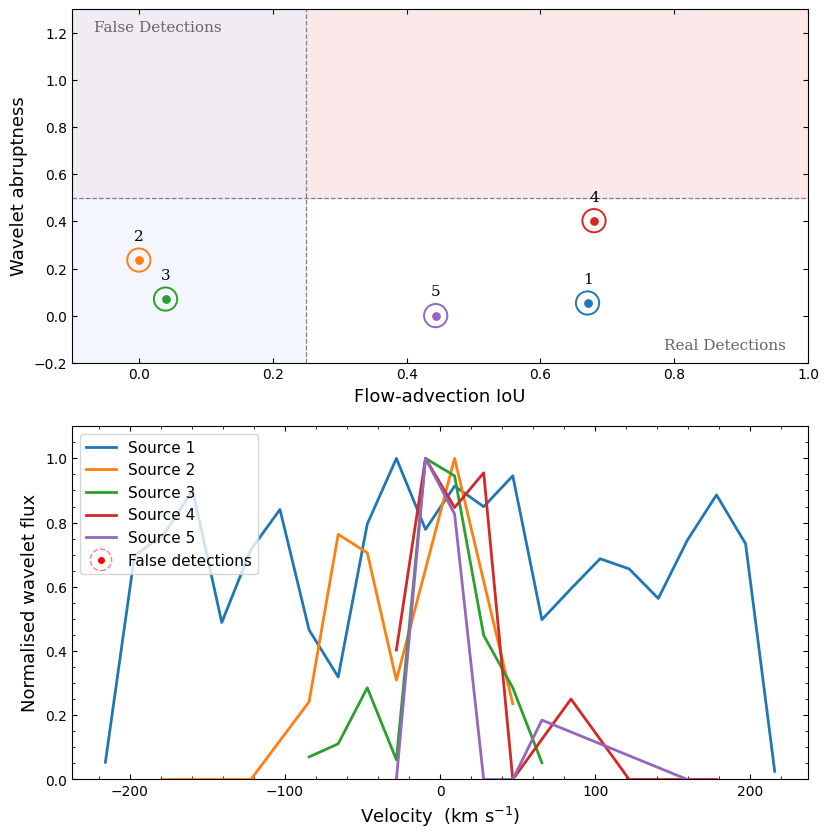

In [10]:
from flow_tracker import run_flow_tracker

_thresh = globals().get('TOY_THRESH', None)

(
    detections, flow_seq, tracks, sources,
    good_sources, false_dets, src_data, src_colors,
) = run_flow_tracker(
    cube,
    channel_list=channel_list,
    scales=5, k_sigma=5.0, use_scale=2, min_area=5,
    thresh=_thresh,
    use_mean_map_sigma=True,
    min_match_overlap=5, min_split_overlap=3, max_gap_dist=15.0, max_gap_channels=5,
    min_displacement=3.0,
    wav_abrupt_thresh=0.5, flow_iou_thresh=0.25,
    verbose=True, plot=True,
    vel_array=vel_array,
    results_dir=_RESULTS_DIR,
)

frames    = [(d.channel, d.image, d.footprint_masks, d.peaks, d.boxes) for d in detections]
flow_data = list(flow_seq)

mask_to_source: dict[int, int] = {}
for t in tracks:
    for ch, mask in t['masks'].items():
        mask_to_source[id(mask)] = t['source_id']

plt.rcParams.update(plt.rcParamsDefault)

In [11]:
def _footprint_overlay(footprint_masks, H, W, alpha=1):
    union = np.zeros((H, W), dtype=bool)
    for m in footprint_masks:
        union |= m
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[~union] = [0, 0, 0, alpha]
    return rgba

## Detection + Optical Flow GIF

In [12]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

_good_ids   = {s['id'] for s in good_sources}
_flow_by_ch = {cr: ff for cr, ct, ff, _ in flow_data}

def _first_ch_src(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999
_good_chrono  = sorted(good_sources, key=_first_ch_src)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}

H, W  = frames[0][1].shape
qs    = 5
ys_q  = np.arange(0, H, qs)
xs_q  = np.arange(0, W, qs)
Xq, Yq = np.meshgrid(xs_q, ys_q)
n_pts   = Xq.size

vmin = min(f[1].min() for f in frames)
vmax = max(f[1].max() for f in frames)

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

fig = plt.figure(figsize=(8, 5))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[0.04, 1],
    hspace=0.06, wspace=0.03,
    left=0.02, right=0.98, top=0.88, bottom=0.04,
)
ax_cb  = fig.add_subplot(gs[0, :])
ax_det = fig.add_subplot(gs[1, 0])
ax_flo = fig.add_subplot(gs[1, 1])
for ax in (ax_det, ax_flo):
    ax.set_xticks([]); ax.set_yticks([])

ax_det.text(0.04, 0.96, 'Detections', transform=ax_det.transAxes,
            va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
ax_flo.text(0.04, 0.96, 'Optical Flow', transform=ax_flo.transAxes,
            va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))

im_l = ax_det.imshow(frames[0][1], cmap='inferno', vmin=vmin, vmax=vmax, origin='lower')
im_r = ax_flo.imshow(frames[0][1], cmap='inferno', vmin=vmin, vmax=vmax, origin='lower')
_first_good = [m for m in frames[0][2]
               if mask_to_source.get(id(m), -1) in _good_ids]
ov   = ax_det.imshow(_footprint_overlay(_first_good, H, W),
                     origin='lower', interpolation='nearest')

quiv = ax_flo.quiver(
    Xq.ravel(), Yq.ravel(), np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts),
    cmap='cool', angles='xy', scale_units='xy', scale=1,
    width=0.003, headwidth=4, headlength=5, alpha=0.9, clim=(0, 3),
)

_sm = plt.cm.ScalarMappable(cmap='inferno', norm=plt.Normalize(vmin=vmin, vmax=vmax))
_cb = fig.colorbar(_sm, cax=ax_cb, orientation='horizontal')
_cb.ax.tick_params(labelsize=10, direction='out')
_cb.set_label('Jy beam$^{-1}$', fontsize=12, labelpad=8)
ax_cb.xaxis.set_ticks_position('top')
ax_cb.xaxis.set_label_position('top')

_ch_text = ax_det.text(0.98, 0.03, '', transform=ax_det.transAxes,
                       va='bottom', ha='right', fontsize=12, color='white',
                       fontfamily='serif',
                       bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.45, ec='none'))

_sb_kpc_gif = max(5.0, round(pixscale_kpc * W * 0.15 / 5) * 5)
_sb_px_gif  = _sb_kpc_gif / pixscale_kpc
_sb_x0_gif  = W * 0.70
_sb_y0_gif  = H * 0.07
ax_flo.plot([_sb_x0_gif, _sb_x0_gif + _sb_px_gif], [_sb_y0_gif, _sb_y0_gif],
            color='white', lw=1.5, zorder=5)
ax_flo.text(_sb_x0_gif + _sb_px_gif / 2, H * 0.12, f'{_sb_kpc_gif:.1f} kpc',
            color='white', ha='center', va='bottom', fontsize=10,
            fontfamily='serif', zorder=5)

_contours, _markers, _bboxes, _blabels = [], [], [], []
_PAD_BB = 4

def _light(color):
    c = np.array(matplotlib.colors.to_rgb(color))
    return tuple(0.3 * c + 0.7)

def _draw_flow_boxes(footprint_masks, peaks):
    for i, mask in enumerate(footprint_masks):
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids: continue
        color  = src_colors.get(sid, (1,1,1,1))
        lcolor = _light(color)
        rows, cols = np.where(mask)
        if len(rows) == 0: continue
        r0, r1 = int(rows.min()), int(rows.max())
        c0, c1 = int(cols.min()), int(cols.max())
        clbl = str(_chrono_label.get(sid, sid + 1))
        rect_r = mpatches.Rectangle(
            (c0 - _PAD_BB, r0 - _PAD_BB),
            c1 - c0 + 2*_PAD_BB, r1 - r0 + 2*_PAD_BB,
            linewidth=0.8, edgecolor=lcolor, facecolor='none', zorder=4
        )
        ax_flo.add_patch(rect_r); _bboxes.append(rect_r)
        _blabels.append(ax_flo.text(
            c1 + _PAD_BB, r1 + _PAD_BB, clbl, ha='center', va='center', fontsize=7,
            color='black', fontweight='bold', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.22', fc=lcolor, ec=lcolor, lw=1.2), zorder=6
        ))
        rect_l = mpatches.Rectangle(
            (c0 - _PAD_BB, r0 - _PAD_BB),
            c1 - c0 + 2*_PAD_BB, r1 - r0 + 2*_PAD_BB,
            linewidth=0.8, edgecolor=lcolor, facecolor='none', alpha=0.35, zorder=4
        )
        ax_det.add_patch(rect_l); _bboxes.append(rect_l)
        _blabels.append(ax_det.text(
            c1 + _PAD_BB, r1 + _PAD_BB, clbl, ha='center', va='center', fontsize=7,
            color='black', fontweight='bold', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.22', fc=lcolor, ec=lcolor, lw=1.2), zorder=6
        ))

# reset before animation
for _cs in list(ax_det.collections):
    try: _cs.remove()
    except: pass
for _ln in list(ax_det.lines):
    try: _ln.remove()
    except: pass
for _bb in _bboxes: _bb.remove()
for _bl in _blabels: _bl.remove()
_bboxes.clear(); _blabels.clear()
im_l.set_data(frames[0][1]); im_r.set_data(frames[0][1])
ov.set_data(_footprint_overlay(
    [m for m in frames[0][2] if mask_to_source.get(id(m),-1) in _good_ids], H, W))
_ch_text.set_text('')

add_beam(ax_det, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(6, 6), color='white')
add_beam(ax_flo, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(6, 6), color='white')

def _update(fi):
    ch, img, footprint_masks, peaks, _ = frames[fi]
    im_l.set_data(img); im_r.set_data(img)
    good_masks = [m for m in footprint_masks
                  if mask_to_source.get(id(m), -1) in _good_ids]
    ov.set_data(_footprint_overlay(good_masks, H, W))
    for cs in _contours: cs.remove()
    _contours.clear()
    for mk in _markers: mk.remove()
    _markers.clear()
    for bb in _bboxes: bb.remove()
    _bboxes.clear()
    for bl in _blabels: bl.remove()
    _blabels.clear()
    for i, mask in enumerate(footprint_masks):
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids: continue
        color = src_colors.get(sid, (1, 1, 1, 1))
        cs = ax_det.contour(mask.astype(float), [0.5], colors=[color], linewidths=0.7)
        _contours.append(cs)
        if i < len(peaks):
            yy, xx = peaks[i]
            mk, = ax_det.plot(xx, yy, marker='+', ms=7, mew=1.0,
                              color=color, linestyle='none')
            _markers.append(mk)
    _draw_flow_boxes(footprint_masks, peaks)
    if ch in _flow_by_ch:
        ff    = _flow_by_ch[ch]
        v_q   = ff[0][ys_q[:, None], xs_q[None, :]].ravel()
        u_q   = ff[1][ys_q[:, None], xs_q[None, :]].ravel()
        mag_q = np.hypot(u_q, v_q)
        pk_m  = float(mag_q.max())
        if pk_m > 1e-6:
            quiv.set_UVC(u_q * qs * 0.8 / pk_m, v_q * qs * 0.8 / pk_m, mag_q)
        else:
            quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))
    else:
        quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))
    _v = float(vel_array[ch])
    _ch_text.set_text(f'ch {ch}  |  $\\mathbf{{{_v:.0f}\\ km\\ s^{{-1}}}}$')
    return [im_l, im_r, ov, _ch_text]

_ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=300, blit=False)
_ani.save(f'{_RESULTS_DIR}/detections_flow.gif', writer='pillow', fps=8)
plt.close(fig)
print(f'Saved {_RESULTS_DIR}/detections_flow.gif  ({len(frames)} frames)')

plt.rcParams.update(plt.rcParamsDefault)

Saved ../results/toy_cube_cube_3/detections_flow.gif  (31 frames)


## Full-field Moment 0 + Moment 1 Overview

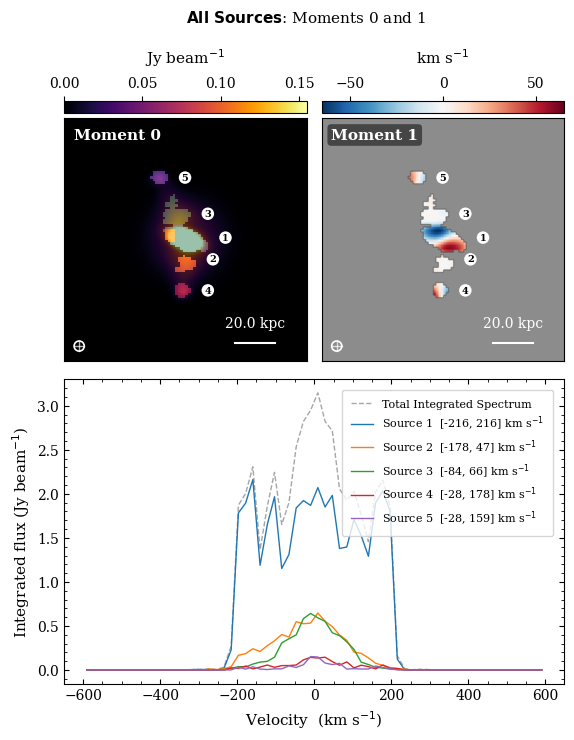

In [13]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family':    'serif',
    'font.size':       11,
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

_nH, _nW = cube.shape[1], cube.shape[2]
_good_ids = {s['id'] for s in good_sources}

_scalebar_kpc = max(5.0, round(pixscale_kpc * _nW * 0.15 / 5) * 5)
_scalebar_px  = _scalebar_kpc / pixscale_kpc

# union footprint per good source
_src_union = {}
for src in good_sources:
    m = np.zeros((_nH, _nW), dtype=bool)
    for t in tracks:
        if t['id'] in src['track_ids']:
            for mask in t['masks'].values():
                m |= mask
    _src_union[src['id']] = m

_all_union = np.zeros((_nH, _nW), dtype=bool)
for m in _src_union.values():
    _all_union |= m

def _first_ch(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(good_sources, key=_first_ch)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}

# Moment 0
_det_chs_all = sorted({
    ch for src in good_sources for t in tracks
    if t['id'] in src['track_ids'] for ch in t['masks']
})
_det_idx   = np.array(_det_chs_all) if _det_chs_all else np.array(channel_list)
_mom0_full = cube[_det_idx].sum(axis=0)

# Moment 1
_flux_stack = cube[_det_idx]
_total_flux = _flux_stack.sum(axis=0)
with np.errstate(invalid='ignore', divide='ignore'):
    _mom1_full = np.where(
        (_total_flux > 0) & _all_union,
        (_flux_stack * vel_array[_det_idx][:, None, None]).sum(axis=0) / _total_flux,
        np.nan,
    )

# RGBA overlay
_rgba = np.zeros((_nH, _nW, 4), dtype=np.float32)
_rgba[~_all_union] = [0, 0, 0, 0.6]
for src in _good_chrono:
    m = _src_union[src['id']]
    if not m.any(): continue
    r, g, b = matplotlib.colors.to_rgb(src_colors[src['id']])
    _rgba[m] = [r, g, b, 0.45]

fig = plt.figure(figsize=(5.5, 7.5))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.1],
    hspace=0.01, wspace=0.06,
    left=0.06, right=0.97, top=0.86, bottom=0.08,
)
ax_m0 = fig.add_subplot(gs[0, 0])
ax_m1 = fig.add_subplot(gs[0, 1])
ax_sp = fig.add_subplot(gs[1, :])

fig.text(0.5, 0.962, r"$\mathbf{All\ Sources}$: Moments 0 and 1",
         ha='center', fontsize=11, fontfamily='serif')

# Moment 0
_v0p, _v1p = np.nanpercentile(_mom0_full, [1, 99])
_im0 = ax_m0.imshow(_mom0_full, cmap='inferno', origin='lower', vmin=_v0p, vmax=_v1p)
ax_m0.imshow(_rgba, origin='lower', interpolation='nearest')
ax_m0.set_xticks([]); ax_m0.set_yticks([])
ax_m0.text(0.04, 0.96, 'Moment 0', transform=ax_m0.transAxes,
           va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
cb0 = fig.colorbar(_im0, ax=ax_m0, location='top', fraction=0.05, pad=0.02)
cb0.ax.tick_params(labelsize=10, direction='out')
cb0.set_label('Jy beam$^{-1}$', fontsize=11, labelpad=10)

_sb_x0  = _nW * 0.70
_sb_y0  = _nH * 0.07
_sb_txt = _nH * 0.12
ax_m0.plot([_sb_x0, _sb_x0 + _scalebar_px], [_sb_y0, _sb_y0], color='white', lw=1.5)
ax_m0.text(_sb_x0 + _scalebar_px / 2, _sb_txt, f'{_scalebar_kpc:.1f} kpc',
           color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

# Moment 1
ax_m1.set_facecolor('0.55')
_mom1_show = np.where(_all_union, _mom1_full, np.nan)
_m1_vmax   = float(np.nanmax(np.abs(_mom1_show)))
_im1 = ax_m1.imshow(_mom1_show, cmap='RdBu_r', origin='lower',
                    vmin=-_m1_vmax, vmax=_m1_vmax)
ax_m1.set_xticks([]); ax_m1.set_yticks([])
ax_m1.text(0.04, 0.96, 'Moment 1', transform=ax_m1.transAxes,
           va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
cb1 = fig.colorbar(_im1, ax=ax_m1, location='top', fraction=0.05, pad=0.02)
cb1.ax.tick_params(labelsize=10, direction='out')
cb1.set_label('km s$^{-1}$', fontsize=11, labelpad=10)

ax_m1.plot([_sb_x0, _sb_x0 + _scalebar_px], [_sb_y0, _sb_y0], color='white', lw=1.5)
ax_m1.text(_sb_x0 + _scalebar_px / 2, _sb_txt, f'{_scalebar_kpc:.1f} kpc',
           color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

add_beam(ax_m0, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(6, 6), color='white')
add_beam(ax_m1, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(6, 6), color='white')

# source number labels
for src in _good_chrono:
    m = _src_union[src['id']]
    if not m.any(): continue
    _rows, _cols = np.where(m)
    _lx = float(_cols.max()) + 6
    _ly = float(_rows.mean())
    _lbl = str(_chrono_label[src['id']])
    for _ax in (ax_m0, ax_m1):
        _ax.text(_lx, _ly, _lbl,
                 ha='left', va='center', fontsize=7,
                 color='black', fontweight='bold', fontfamily='serif',
                 bbox=dict(boxstyle='circle,pad=0.18', fc='white', ec='none'),
                 zorder=6)

# Spectrum
_total_spec = cube[:, _all_union].sum(axis=1)
ax_sp.plot(vel_array, _total_spec, color='0.65', lw=1, ls='--', zorder=2)

for src in _good_chrono:
    if not _src_union[src['id']].any(): continue
    _src_spec = cube[:, _src_union[src['id']]].sum(axis=1)
    ax_sp.plot(vel_array, _src_spec, color=src_colors[src['id']], lw=1, zorder=3)

ax_sp.set_xlabel('Velocity  (km s$^{-1}$)', fontsize=11)
ax_sp.set_ylabel('Integrated flux (Jy beam$^{-1}$)', fontsize=11)
ax_sp.tick_params(which='both', direction='in', top=True, right=True)
ax_sp.minorticks_on()

_leg_handles = [Line2D([0], [0], color='0.65', lw=1, ls='--',
                       label='Total Integrated Spectrum')]
for src in _good_chrono:
    if not _src_union[src['id']].any(): continue
    det_chs = sorted(ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks'])
    if det_chs:
        _v0det = float(vel_array[det_chs[0]])
        _v1det = float(vel_array[det_chs[-1]])
        _vlbl  = f"[{_v0det:.0f}, {_v1det:.0f}] km s$^{{-1}}$"
    else:
        _vlbl = 'no det'
    _leg_handles.append(Line2D([0], [0], color=src_colors[src['id']], lw=1,
                               label=f"Source {_chrono_label[src['id']]}  {_vlbl}"))

ax_sp.legend(handles=_leg_handles, fontsize=8,
             borderpad=0.8, borderaxespad=1, labelspacing=0.5)

plt.savefig(f'{_RESULTS_DIR}/fullfield_moments.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/fullfield_moments.pdf', dpi=130, bbox_inches='tight')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

## Per-source Diagnostic Plots

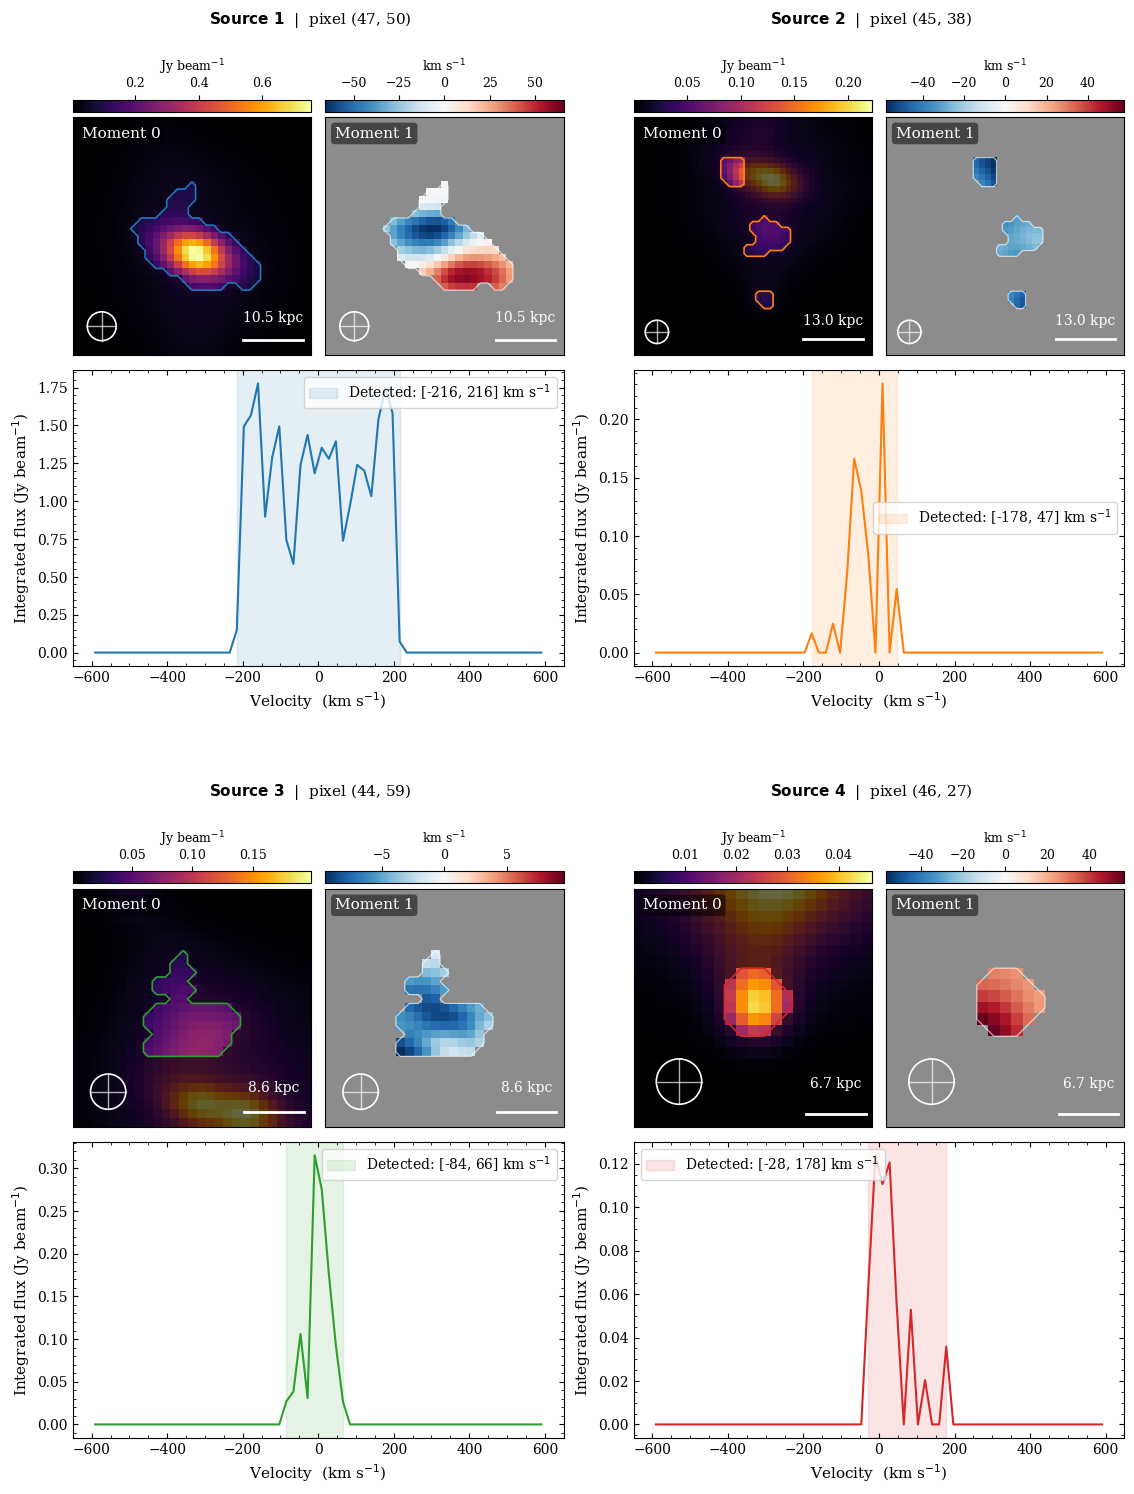

Saved ../results/toy_cube_cube_3/sources_diag_page1.png


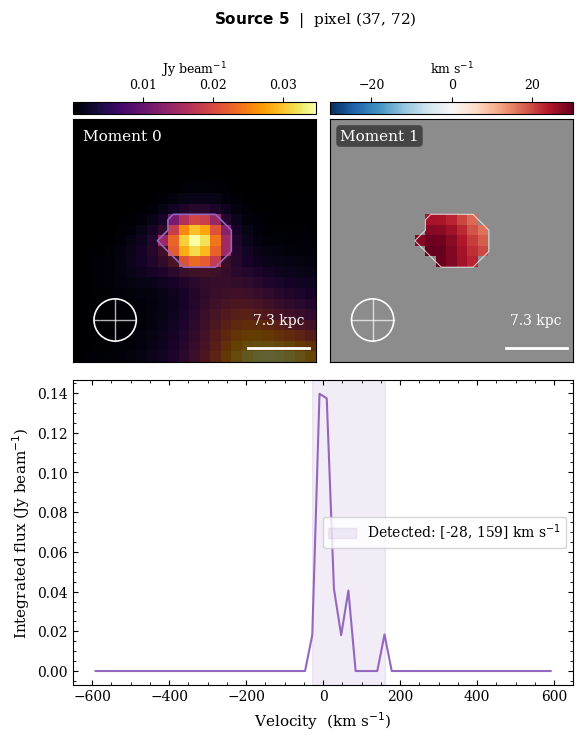

Saved ../results/toy_cube_cube_3/sources_diag_page2.png


In [14]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)
import math

_PAD  = 8
_nH, _nW = cube.shape[1], cube.shape[2]

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


def _plot_source_diag(src, subfig):
    src_tracks_here = [t for t in tracks if t['id'] in src['track_ids']]

    union_mask = np.zeros((_nH, _nW), dtype=bool)
    ch_to_mask = {}
    for t in src_tracks_here:
        for ch, mask in t['masks'].items():
            union_mask |= mask
            ch_to_mask[ch] = ch_to_mask.get(ch, np.zeros((_nH, _nW), dtype=bool)) | mask

    if not union_mask.any():
        return
    det_channels = sorted(ch_to_mask.keys())

    rows_nz = np.where(union_mask.any(axis=1))[0]
    cols_nz = np.where(union_mask.any(axis=0))[0]
    cy   = (int(rows_nz[0]) + int(rows_nz[-1])) // 2
    cx   = (int(cols_nz[0]) + int(cols_nz[-1])) // 2
    half = max(int(rows_nz[-1]) - int(rows_nz[0]),
               int(cols_nz[-1]) - int(cols_nz[0])) // 2 + _PAD
    y0 = max(0, cy - half);  y1 = min(_nH, cy + half + 1)
    x0 = max(0, cx - half);  x1 = min(_nW, cx + half + 1)

    det_idx        = np.array(det_channels)
    footprint_crop = union_mask[y0:y1, x0:x1]
    mom0_crop = cube[det_idx].sum(axis=0)[y0:y1, x0:x1]

    flux_crop  = cube[det_idx][:, y0:y1, x0:x1]
    total_flux = flux_crop.sum(axis=0)
    with np.errstate(invalid='ignore', divide='ignore'):
        mom1_show = np.where(
            (total_flux > 0) & footprint_crop,
            (flux_crop * vel_array[det_idx][:, None, None]).sum(axis=0) / total_flux,
            np.nan,
        )

    spec_chs  = np.arange(cube.shape[0])
    spec_vels = vel_array[spec_chs]
    spec_flux = np.array([
        float(cube[ch][ch_to_mask[ch]].sum()) if ch in ch_to_mask else 0.0
        for ch in spec_chs
    ])

    color = src_colors[src['id']]
    gs    = subfig.add_gridspec(2, 2, height_ratios=[1, 1.1],
                                hspace=0.01, wspace=0.06,
                                left=0.06, right=0.97, top=0.86, bottom=0.08)
    ax_m0 = subfig.add_subplot(gs[0, 0])
    ax_m1 = subfig.add_subplot(gs[0, 1])
    ax_sp = subfig.add_subplot(gs[1, :])

    # Moment 0
    _ov0 = np.zeros(footprint_crop.shape + (4,), dtype=np.float32)
    _ov0[~footprint_crop] = [0, 0, 0, 0.6]
    im0 = ax_m0.imshow(mom0_crop, cmap='inferno', origin='lower')
    ax_m0.imshow(_ov0, origin='lower', interpolation='nearest')
    ax_m0.contour(footprint_crop.astype(float), [0.5],
                  colors=[color], linewidths=1.2)
    ax_m0.set_xticks([]); ax_m0.set_yticks([])
    ax_m0.text(0.04, 0.96, 'Moment 0', transform=ax_m0.transAxes,
               va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
               bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
    cb0 = subfig.colorbar(im0, ax=ax_m0, location='top', fraction=0.05, pad=0.02)
    cb0.ax.tick_params(labelsize=9, direction='out')
    cb0.set_label('Jy beam$^{-1}$', fontsize=9)

    # Moment 1
    ax_m1.set_facecolor('0.55')
    _m1v = float(np.nanmax(np.abs(mom1_show))) if np.any(np.isfinite(mom1_show)) else 1.0
    im1 = ax_m1.imshow(mom1_show, cmap='RdBu_r', origin='lower',
                       vmin=-_m1v, vmax=_m1v)
    ax_m1.contour(footprint_crop.astype(float), [0.5],
                  colors='white', linewidths=0.8, alpha=0.7)
    ax_m1.set_xticks([]); ax_m1.set_yticks([])
    ax_m1.text(0.04, 0.96, 'Moment 1', transform=ax_m1.transAxes,
               va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
               bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
    cb1 = subfig.colorbar(im1, ax=ax_m1, location='top', fraction=0.05, pad=0.02)
    cb1.ax.tick_params(labelsize=9, direction='out')
    cb1.set_label('km s$^{-1}$', fontsize=9)

    add_beam(ax_m0, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(4, 4), color='white')
    add_beam(ax_m1, BMIN_PIX, BMAJ_PIX, BPA_DEG, xy_offset=(4, 4), color='white')

    # Spectrum
    ax_sp.plot(spec_vels, spec_flux, color=color, lw=1.5)
    _v0_det = float(vel_array[det_channels[0]])
    _v1_det = float(vel_array[det_channels[-1]])
    ax_sp.axvspan(min(_v0_det, _v1_det), max(_v0_det, _v1_det),
                  alpha=0.12, color=color,
                  label=f'Detected: [{_v0_det:.0f}, {_v1_det:.0f}] km s$^{{-1}}$')
    ax_sp.set_xlabel('Velocity  (km s$^{-1}$)', fontsize=11)
    ax_sp.set_ylabel('Integrated flux (Jy beam$^{-1}$)', fontsize=11)
    ax_sp.tick_params(which='both', direction='in', top=True, right=True)
    ax_sp.minorticks_on()
    ax_sp.legend(fontsize=10)

    subfig.text(0.5, 0.962,
                f"$\\mathbf{{Source\\ {_chrono_label[src['id']]}}}"
                f"$  |  pixel ({cx}, {cy})",
                ha='center', fontsize=11, fontfamily='serif')

    _bw_kpc = (x1 - x0) * pixscale_kpc
    _sb_kpc = _bw_kpc * 0.25
    _sb_px  = _sb_kpc / pixscale_kpc
    _sb_x0  = (x1 - x0) * 0.70
    _sb_y0_ = (y1 - y0) * 0.08 - 1
    _sb_txt_ = _sb_y0_ + 2
    for _sax, _scol in [(ax_m0, 'white'), (ax_m1, 'white')]:
        _sax.plot([_sb_x0, _sb_x0 + _sb_px], [_sb_y0_, _sb_y0_], color=_scol, lw=2)
        _sax.text(_sb_x0 + _sb_px / 2, _sb_txt_, f'{_sb_kpc:.1f} kpc', color=_scol,
                  ha='center', va='bottom', fontsize=10, fontfamily='serif')


_src_chunks = [good_sources[i:i+4] for i in range(0, len(good_sources), 4)]

for _ci, chunk in enumerate(_src_chunks):
    n     = len(chunk)
    nrows = math.ceil(n / 2)
    ncols = min(n, 2)
    fig   = plt.figure(figsize=(ncols * 5.5, nrows * 7.5))
    sfs   = fig.subfigures(nrows, ncols, wspace=0.04, hspace=0.06)
    sfs_flat = np.array(sfs).flatten()

    for src, sf in zip(chunk, sfs_flat):
        _plot_source_diag(src, sf)

    for sf in sfs_flat[n:]:
        sf.set_visible(False)

    fname_base = f"{_RESULTS_DIR}/sources_diag_page{_ci+1}"
    plt.savefig(fname_base + '.png', dpi=130, bbox_inches='tight')
    plt.savefig(fname_base + '.pdf', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname_base}.png')

plt.rcParams.update(plt.rcParamsDefault)

## Kinematic Trajectories

In [ ]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':   'serif',
    'font.size':      11,
    'axes.labelsize': 11,
    'xtick.labelsize':10,
    'ytick.labelsize':10,
})

def _first_ch(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(good_sources, key=_first_ch)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}
_good_ids     = {s['id'] for s in good_sources}
_good_tracks  = [t for t in tracks if t['source_id'] in _good_ids]

mean_img = cube[channel_list[len(channel_list)//2 - 2] :
                channel_list[len(channel_list)//2 + 3]].mean(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(mean_img, cmap='inferno', origin='lower')
ax.set_xlabel('Pixel X', fontsize=11)
ax.set_ylabel('Pixel Y', fontsize=11)
ax.tick_params(which='both', direction='in', top=True, right=True)
fig.text(0.5, 0.98,
         r"$\mathbf{Good\ Sources}$: Kinematic Trajectories",
         ha='center', fontsize=11, fontfamily='serif')

for t in _good_tracks:
    sid   = t['source_id']
    color = src_colors[sid]
    clbl  = _chrono_label[sid]
    ys_t  = [p[1] for p in t['trajectory']]
    xs_t  = [p[2] for p in t['trajectory']]
    lw    = 1.8 if t['kinematic'] else 0.8
    alpha = 0.95 if t['kinematic'] else 0.4
    ax.plot(xs_t, ys_t, color=color, lw=lw, alpha=alpha)
    ax.scatter(xs_t[0],  ys_t[0],  s=40, color=color, zorder=5, marker='o', alpha=alpha)
    ax.scatter(xs_t[-1], ys_t[-1], s=60, color=color, zorder=5, marker='^', alpha=alpha)
    ax.text(xs_t[0], ys_t[0] - 4, str(clbl), color='black',
            fontsize=7, ha='center', va='top', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.18', fc='white', ec='none'), zorder=6)
    for ch_sp in t['split_at']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_sp:
                ax.plot(sx, sy, marker='*', ms=12, color=color, zorder=6)
                break
    for ch_mg, _ in t['merge_into']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_mg:
                ax.plot(sx, sy, marker='D', ms=8, color=color, zorder=6, alpha=0.7)
                break

_patches = [mpatches.Patch(color=src_colors[s['id']],
                            label=f"Source {_chrono_label[s['id']]}")
            for s in _good_chrono]
ax.legend(handles=_patches, loc='upper right', fontsize=9,
          framealpha=0.75, edgecolor='0.3')

plt.tight_layout()
plt.savefig(f'{_RESULTS_DIR}/trajectories.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/trajectories.pdf', dpi=130, bbox_inches='tight')
plt.show()
print('Saved trajectories.png')

# animated GIF — channel-by-channel
fig2, ax2 = plt.subplots(figsize=(5.5, 5.5))
ax2.set_xlabel('Pixel X', fontsize=11)
ax2.set_ylabel('Pixel Y', fontsize=11)
title2  = ax2.set_title('')
im_bg   = ax2.imshow(frames[0][1], cmap='inferno',
                     vmin=mean_img.min(), vmax=mean_img.max(), origin='lower')

line_artists, scatter_artists, contour_sets2 = [], [], []

def _update_traj(fi):
    ch, img, footprint_masks, peaks, _ = frames[fi]
    im_bg.set_data(img)
    title2.set_text(f'Channel {ch}')
    for a in line_artists + scatter_artists:
        a.remove()
    line_artists.clear(); scatter_artists.clear()
    for cs in contour_sets2:
        cs.remove()
    contour_sets2.clear()
    for mask in footprint_masks:
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids:
            continue
        color = src_colors.get(sid, (1.0, 1.0, 1.0, 1.0))
        cs = ax2.contour(mask.astype(float), [0.5], colors=[color], linewidths=1.2)
        contour_sets2.append(cs)
    for t in _good_tracks:
        sid   = t['source_id']
        color = src_colors[sid]
        past  = [(py, px) for tc, py, px in t['trajectory'] if tc <= ch]
        if not past:
            continue
        lw    = 2.0 if t['kinematic'] else 0.8
        alpha = 0.95 if t['kinematic'] else 0.4
        ln, = ax2.plot([p[1] for p in past], [p[0] for p in past],
                       color=color, lw=lw, alpha=alpha)
        sc  = ax2.scatter(past[-1][1], past[-1][0],
                          s=50, color=color, zorder=5, alpha=alpha)
        line_artists.append(ln); scatter_artists.append(sc)
    return [im_bg, title2]

ani2 = animation.FuncAnimation(fig2, _update_traj, frames=len(frames), interval=700, blit=False)
ani2.save(f'{_RESULTS_DIR}/kinematic_tracks.gif', writer='pillow', fps=1)
plt.close(fig2)
print(f'Saved {_RESULTS_DIR}/kinematic_tracks.gif')

plt.rcParams.update(plt.rcParamsDefault)

## Ground-truth Comparison

Compare the detected sources (footprint + bounding box) against the **clean individual galaxy cubes** stored in `galaxies/cubes` of the HDF5 file.

For each ground-truth galaxy we:
1. Compute its spatial footprint = pixels where `galaxy_mom0 > threshold × max(galaxy_mom0)`
2. Find the best-matching detected source by spatial centroid proximity
3. Overlay the detected footprint (colored contour) and bounding box on the galaxy's moment-0 map
4. Report per-galaxy **IoU** (intersection-over-union of spatial footprints) and **centroid offset** in kpc

In [ ]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size':    11,
})

# ── Re-use previously computed union footprints from good_sources ─────────
# (recompute in case this cell is run standalone)
_nH, _nW = cube.shape[1], cube.shape[2]
_good_ids = {s['id'] for s in good_sources}

def _first_ch(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(good_sources, key=_first_ch)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}

_src_union_fp = {}
_src_bbox     = {}  # (r0, r1, c0, c1)
for src in good_sources:
    m = np.zeros((_nH, _nW), dtype=bool)
    for t in tracks:
        if t['id'] in src['track_ids']:
            for mask in t['masks'].values():
                m |= mask
    _src_union_fp[src['id']] = m
    if m.any():
        rs, cs = np.where(m)
        _src_bbox[src['id']] = (int(rs.min()), int(rs.max()),
                                 int(cs.min()), int(cs.max()))

# centroid of each detected source
_src_centroid = {}
for src in good_sources:
    m = _src_union_fp[src['id']]
    if m.any():
        rs, cs = np.where(m)
        _src_centroid[src['id']] = (float(rs.mean()), float(cs.mean()))

# ── Ground-truth galaxy footprints from clean cubes ───────────────────────
_GT_THRESH_FRAC = 0.05   # fraction of peak mom0 to define galaxy footprint

_gt_mom0     = []   # moment-0 map per galaxy (H, W)
_gt_fp       = []   # binary footprint (H, W)
_gt_centroid = []   # (cy, cx) in pixel
_gt_bbox     = []   # (r0, r1, c0, c1)

for gi in range(n_gals):
    gal_cube = _gal_cubes[gi].copy()
    np.nan_to_num(gal_cube, copy=False, nan=0.0)
    np.clip(gal_cube, 0.0, None, out=gal_cube)
    mom0 = gal_cube[np.array(channel_list)].sum(axis=0)
    thresh_gt = _GT_THRESH_FRAC * float(mom0.max()) if mom0.max() > 0 else 1e-30
    fp   = mom0 > thresh_gt
    _gt_mom0.append(mom0)
    _gt_fp.append(fp)
    if fp.any():
        rs, cs = np.where(fp)
        _gt_centroid.append((float(rs.mean()), float(cs.mean())))
        _gt_bbox.append((int(rs.min()), int(rs.max()), int(cs.min()), int(cs.max())))
    else:
        # fall back to h5 position (x = col, y = row in image convention)
        pos = _gal_pos_xyz[gi]
        _gt_centroid.append((float(pos[1]), float(pos[0])))
        _gt_bbox.append((int(pos[1]), int(pos[1]), int(pos[0]), int(pos[0])))

# ── Match detected sources → ground-truth galaxies ────────────────────────
# Greedy nearest-centroid matching (distance in pixels)
import itertools

det_ids  = [src['id'] for src in good_sources if src['id'] in _src_centroid]
gt_idx   = list(range(n_gals))

_match_det2gt = {}   # det src_id  → gt galaxy index
_match_gt2det = {}   # gt galaxy index → det src_id

# build distance matrix
_dist = np.full((len(det_ids), n_gals), np.inf)
for di, sid in enumerate(det_ids):
    cy_d, cx_d = _src_centroid[sid]
    for gi in range(n_gals):
        cy_g, cx_g = _gt_centroid[gi]
        _dist[di, gi] = np.hypot(cy_d - cy_g, cx_d - cx_g)

# greedy matching (closest pair first)
_matched_det = set()
_matched_gt  = set()
for _ in range(min(len(det_ids), n_gals)):
    if _dist.size == 0: break
    di_best, gi_best = np.unravel_index(np.argmin(_dist), _dist.shape)
    if np.isinf(_dist[di_best, gi_best]): break
    sid = det_ids[di_best]
    _match_det2gt[sid]  = gt_idx[gi_best]
    _match_gt2det[gt_idx[gi_best]] = sid
    _dist[di_best, :] = np.inf
    _dist[:, gi_best] = np.inf

# ── IoU calculation ───────────────────────────────────────────────────────
def _iou(fp_a, fp_b):
    inter = (fp_a & fp_b).sum()
    union = (fp_a | fp_b).sum()
    return float(inter) / float(union) if union > 0 else 0.0

# ── Comparison figure ─────────────────────────────────────────────────────
# One row per ground-truth galaxy; 3 columns:
#   col 0: clean galaxy moment-0  +  detected footprint contour  +  bbox
#   col 1: detected source moment-0  (or blank if undetected)
#   col 2: overlap map  (intersection = green, FP = red, FN = blue)

_PAD_CMP = 10   # padding around the zoomed-in crop

fig_cmp, axes_cmp = plt.subplots(
    n_gals, 3,
    figsize=(11, 3.8 * n_gals),
    squeeze=False,
)
fig_cmp.suptitle(
    f'Ground-truth vs. Detected Sources  —  {_CUBE_PATH.name}',
    fontsize=12, fontfamily='serif', y=1.01,
)

_metrics = []

for gi in range(n_gals):
    gtype   = _gal_types[gi]
    gt_m0   = _gt_mom0[gi]
    gt_fp_i = _gt_fp[gi]
    gt_cy, gt_cx = _gt_centroid[gi]
    r0_gt, r1_gt, c0_gt, c1_gt = _gt_bbox[gi]

    # crop region centred on ground-truth extent
    _half = max(r1_gt - r0_gt, c1_gt - c0_gt) // 2 + _PAD_CMP
    _half = max(_half, 12)  # at least 12 px half-width
    cy_i, cx_i = int(round(gt_cy)), int(round(gt_cx))
    yr0 = max(0, cy_i - _half); yr1 = min(_nH, cy_i + _half + 1)
    xr0 = max(0, cx_i - _half); xr1 = min(_nW, cx_i + _half + 1)

    # matched detection
    sid_match  = _match_gt2det.get(gi, None)
    det_fp_i   = _src_union_fp[sid_match] if sid_match is not None else np.zeros((_nH, _nW), dtype=bool)
    det_color  = src_colors.get(sid_match, 'white') if sid_match is not None else 'white'
    det_label  = f"Source {_chrono_label[sid_match]}" if sid_match is not None else 'undetected'

    # detected moment-0 within det footprint
    if sid_match is not None:
        _det_chs_src = sorted({
            ch for t in tracks if t['id'] in
            next(s for s in good_sources if s['id'] == sid_match)['track_ids']
            for ch in t['masks']
        })
        det_m0 = cube[np.array(_det_chs_src)].sum(axis=0)
    else:
        det_m0 = np.zeros((_nH, _nW), dtype=np.float32)

    # metrics
    iou_val = _iou(gt_fp_i, det_fp_i)
    if sid_match is not None:
        det_cy, det_cx = _src_centroid[sid_match]
        cen_offset_px  = np.hypot(det_cy - gt_cy, det_cx - gt_cx)
        cen_offset_kpc = cen_offset_px * pixscale_kpc
    else:
        cen_offset_px  = np.nan
        cen_offset_kpc = np.nan
    _metrics.append(dict(galaxy=gi, type=gtype, matched_source=det_label,
                         iou=iou_val, centroid_offset_px=cen_offset_px,
                         centroid_offset_kpc=cen_offset_kpc))

    ax0, ax1, ax2_ = axes_cmp[gi]

    # ── col 0: clean galaxy moment-0 + detected footprint overlay ─────────
    _gt_crop  = gt_m0[yr0:yr1, xr0:xr1]
    _det_crop = det_fp_i[yr0:yr1, xr0:xr1]
    _gt_fp_crop = gt_fp_i[yr0:yr1, xr0:xr1]

    _vp0, _vp1 = np.nanpercentile(_gt_crop, [1, 99]) if _gt_crop.max() > 0 else (0, 1)
    ax0.imshow(_gt_crop, cmap='inferno', origin='lower', vmin=_vp0, vmax=_vp1)
    if _gt_fp_crop.any():
        ax0.contour(_gt_fp_crop.astype(float), [0.5],
                    colors=['cyan'], linewidths=1.0, linestyles='--')
    if _det_crop.any():
        ax0.contour(_det_crop.astype(float), [0.5],
                    colors=[det_color], linewidths=1.2)
        _dr, _dc = np.where(_det_crop)
        _bb_det = mpatches.Rectangle(
            (_dc.min() - 1, _dr.min() - 1),
            _dc.max() - _dc.min() + 2, _dr.max() - _dr.min() + 2,
            linewidth=1.2, edgecolor=det_color, facecolor='none', zorder=5,
        )
        ax0.add_patch(_bb_det)
    # ground-truth bbox
    _bb_gt = mpatches.Rectangle(
        (c0_gt - xr0 - 1, r0_gt - yr0 - 1),
        c1_gt - c0_gt + 2, r1_gt - r0_gt + 2,
        linewidth=1.0, edgecolor='cyan', facecolor='none',
        linestyle='--', zorder=5,
    )
    ax0.add_patch(_bb_gt)
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_title(f'Galaxy {gi}  ({gtype})\nClean mom0', fontsize=10, fontfamily='serif')
    ax0.text(0.02, 0.98,
             f'cyan dashes = GT  |  solid = {det_label}',
             transform=ax0.transAxes, fontsize=7, color='white', va='top',
             bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5, ec='none'))

    # ── col 1: detected source moment-0 ───────────────────────────────────
    _det_m0_crop = det_m0[yr0:yr1, xr0:xr1]
    _vd0, _vd1 = np.nanpercentile(_det_m0_crop, [1, 99]) if _det_m0_crop.max() > 0 else (0, 1)
    ax1.imshow(_det_m0_crop, cmap='inferno', origin='lower', vmin=_vd0, vmax=_vd1)
    if _det_crop.any():
        ax1.contour(_det_crop.astype(float), [0.5],
                    colors=[det_color], linewidths=1.2)
    ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title(f'Detected: {det_label}\nDetected mom0', fontsize=10, fontfamily='serif')
    ax1.text(0.02, 0.98,
             f'IoU = {iou_val:.3f}\nΔcen = {cen_offset_kpc:.2f} kpc',
             transform=ax1.transAxes, fontsize=8, color='white', va='top',
             bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.55, ec='none'))

    # ── col 2: overlap map (TP=green, FP=red, FN=blue, neither=grey) ───────
    _tp = _gt_fp_crop & _det_crop
    _fp = (~_gt_fp_crop) & _det_crop
    _fn = _gt_fp_crop & (~_det_crop)
    _overlap_rgb = np.zeros((_gt_crop.shape[0], _gt_crop.shape[1], 3), dtype=np.float32)
    _overlap_rgb[~_gt_fp_crop & ~_det_crop] = [0.25, 0.25, 0.25]  # background
    _overlap_rgb[_tp] = [0.20, 0.80, 0.30]   # TP  green
    _overlap_rgb[_fp] = [0.90, 0.20, 0.20]   # FP  red
    _overlap_rgb[_fn] = [0.20, 0.40, 0.90]   # FN  blue
    ax2_.imshow(_overlap_rgb, origin='lower')
    ax2_.set_xticks([]); ax2_.set_yticks([])
    ax2_.set_title('Overlap map\nTP=green  FP=red  FN=blue', fontsize=10, fontfamily='serif')
    ax2_.text(0.02, 0.98,
              f'TP={_tp.sum()}  FP={_fp.sum()}  FN={_fn.sum()}',
              transform=ax2_.transAxes, fontsize=8, color='white', va='top',
              bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.55, ec='none'))

plt.tight_layout()
plt.savefig(f'{_RESULTS_DIR}/ground_truth_comparison.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/ground_truth_comparison.pdf', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved {_RESULTS_DIR}/ground_truth_comparison.png')

# ── Summary table ─────────────────────────────────────────────────────────
print()
print(f"{'Galaxy':>8}  {'Type':>12}  {'Matched':>14}  {'IoU':>6}  {'Δcen (px)':>10}  {'Δcen (kpc)':>11}")
print('-' * 70)
for m in _metrics:
    _iou_s  = f"{m['iou']:.3f}"
    _dpx_s  = f"{m['centroid_offset_px']:.2f}" if not np.isnan(m['centroid_offset_px']) else '  —'
    _dkpc_s = f"{m['centroid_offset_kpc']:.2f}" if not np.isnan(m['centroid_offset_kpc']) else '  —'
    print(f"{m['galaxy']:>8}  {m['type']:>12}  {m['matched_source']:>14}  "
          f"{_iou_s:>6}  {_dpx_s:>10}  {_dkpc_s:>11}")

plt.rcParams.update(plt.rcParamsDefault)